## Problema 9 - Minimos cuadrados con Newton-Raphson multidimensional
### Consideraciones para la Resolución

* **Utilizar seis decimales para los resultados.**
* **Utilizar todos los decimales para los calculos.**
* **No utilizar formato exponencial (notacion científica).**
* **Utilizar una tolerancia de $10^{-3}$.**
* **No modificar los valores iniciales ni la tolerancia para los calculos.**
* **No es necesario realizar ninguna conversion de unidades.**

Determinar los coeficientes de modo a que la curva de regresión se ajuste lo mejor posible a los datos. UTILIZAR el método de Newton Raphson generalizado para minimizar el error cuadrático medio siendo el modelo propuesto:

$$
y=Cxe^{-Dx}
$$

Los datos para el ajuste son:

| x | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|
| y | 30.31 | 36.82 | 33.47 | 27.18 | 20.43 | 14.95 | 10.57 | 7.30 | 4.94 |

_Planteamiento_

Siendo $y=Cxe^{-Dx}$ el modelo propuesto, el objetivo de la regresión es determinar $C$ y $D$ tal que se minimice el error cuadrático medio en el conjunto de puntos $(x_1, y_1), \ldots, (x_n, y_n)$.

Es decir, minimizar:
$$ECM_y = \frac{1}{n}\sum_{i=1}^{n}(y_i-y(x_i))^2$$
En terminos de optimizacion se traduce a resolver $\nabla ECM_y = 0$, es decir:
$$\frac{\partial ECM_y}{\partial A} = 0 \quad \text{(1)}$$
$$\frac{\partial ECM_y}{\partial B} = 0 \quad \text{(2)}$$

Sin embargo, para determinar si el modelo es adecuado, este debe ser transformado a un formato $z = aw + b$, de modo a emplear el coeficiente de determinación
$$
R^2 = 1-\frac{\sum_{i=1}^{n}(z_i-z(w_i))^2}{\sum_{i=1}^{n}(z_i-\bar{z})^2}
$$

El modelo es adecuado si $R^2 \geq 0.7$.

Manipulando la ecuación original

$$
\ln(\frac{y}{x}) = \ln(Ce^{-Dx})
$$

$$
\ln(\frac{y}{x}) = \ln(C) - D\ln(x)
$$

Entoces si $z = \ln(\frac{y}{x})$ y $w = \ln(x)$, resulta: el modelo $z = aw + b$ donde $a = -D$ y $b = \ln(C)$, y los datos se transforma a

| w | $\ln(1)$ | $\ln(2)$ | $\ln(3)$ | $\ln(4)$ | $\ln(5)$ | $\ln(6)$ | $\ln(7)$ | $\ln(8)$ | $\ln(9)$ |
|---|---|---|---|---|---|---|---|---|---|
| z | $\ln(\frac{30.31}{1})$ | $\ln(\frac{36.82}{2})$ | $\ln(\frac{33.47}{3})$ | $\ln(\frac{27.18}{4})$ | $\ln(\frac{20.43}{5})$ | $\ln(\frac{14.95}{6})$ | $\ln(\frac{10.57}{7})$ | $\ln(\frac{7.30}{8})$ | $\ln(\frac{4.94}{9})$ |

El Error Cuadrático Medio es:
$$
ECM_z = \frac{1}{n}\sum_{i=1}^{n}(z_i-z(w_i))^2
$$
Y el sistema de a resolver es:
$$\frac{\partial ECM_z}{\partial A} = 0 \quad \text{(1)}$$
$$\frac{\partial ECM_z}{\partial B} = 0 \quad \text{(2)}$$


In [ ]:
import jax.numpy as jnp
from jax import grad
from jax import jacfwd

# Definimos los datos originales
x_data = jnp.array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=float)
y_data = jnp.array([30.31, 36.82, 33.47, 27.18, 20.43, 14.95, 10.57, 7.30, 4.94], dtype=float)

# Transformacion de los datos z = ln(y/x); w = ln(x)
z_data = jnp.log(y_data / x_data)
w_data = jnp.log(x_data)

# Definimos el modelo original
def y(x,C,D):
    return C*x*jnp.exp(-D*x)

# Definimos el modelo trasformado
def z(w,A,B):
    return A*w + B

# Definimos el ECM
def ecm(var):
    A,B = var
    return jnp.mean(jnp.pow(z(w_data,A,B)-z_data,2))

sistema = grad(ecm)
jacob_sist=jacfwd(sistema)

# PARAMETROS DE INICIALIZACION
P0 = jnp.array([0.0, 1.0], dtype=float)
tol = 1e-3
m = 100

################RUTINA009##########################
for i in range(m):
    F = sistema(P0)
    J = jacob_sist(P0)
    deltaP = jnp.linalg.solve(J, -F)
    P = P0 + deltaP
    err = jnp.linalg.norm(deltaP)
    relerr = err / jnp.linalg.norm(P)
    f_norm = jnp.linalg.norm(F)
    if (err < tol) or (relerr < tol) or (f_norm < tol):
        P0 = P
        break
    P0 = P

print("Analsis de convergencia:")
print("Error absoluto: ", err)
print("Error relativo: ", relerr)
print("Cantidad de iteraciones: ", i+1)
print("Valor de |F(P)|: ", f_norm)

print("------------------")
A_res, B_res = P

print("Coeficiente de determinacion: ")
z_pred = z(w_data, A_res, B_res)
z_media = jnp.mean(z_data)

ss_res = jnp.sum(jnp.pow(z_data - z_pred, 2))
ss_tot = jnp.sum(jnp.pow(z_data - z_media, 2))

r2 = 1 - (ss_res / ss_tot)
print("R2: ", r2)
print("------------------")

C = jnp.exp(B_res)
D = -A_res

print("a) Valor de C: ", jnp.around(C,6))
print("b) Valor de D: ", jnp.around(D,6))


Analsis de convergencia:
Error absoluto:  4.4635817e-07
Error relativo:  1.1307366e-07
Cantidad de iteraciones:  2
Valor de |F(P)|:  1.005934e-06
------------------
Coeficiente de determinacion: 
R2:  -1.4874604
------------------
a) Valor de C:  50.177845
b) Valor de D:  0.50103


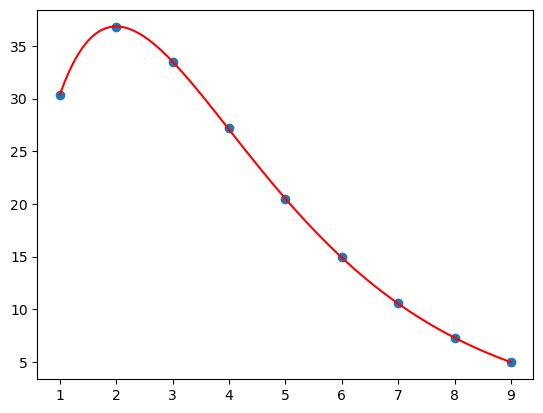

In [ ]:
import matplotlib.pyplot as plt
xf = jnp.linspace(x_data.min(), x_data.max(), 100)
yf = y(xf, C,D)
plt.scatter(x_data, y_data)
plt.plot(xf, yf, color='red')